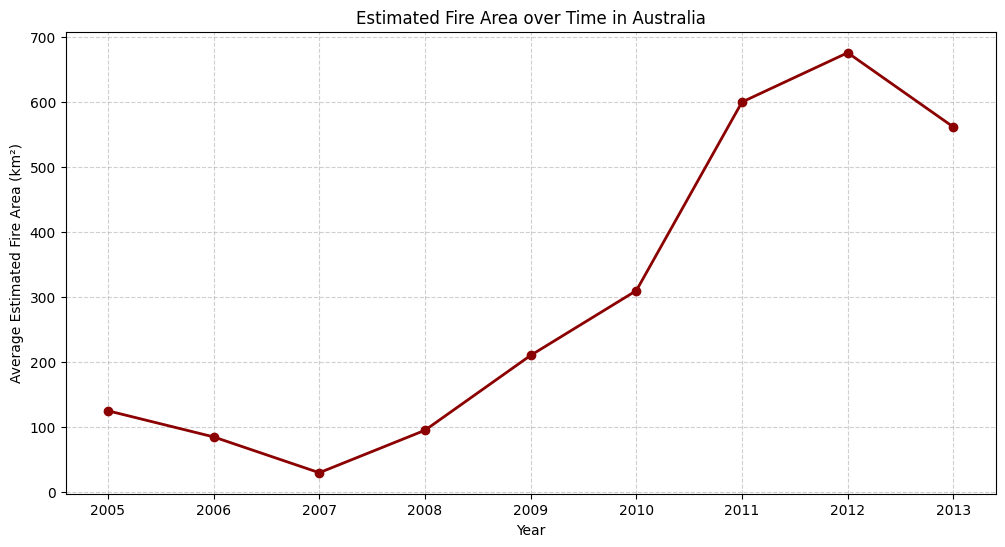

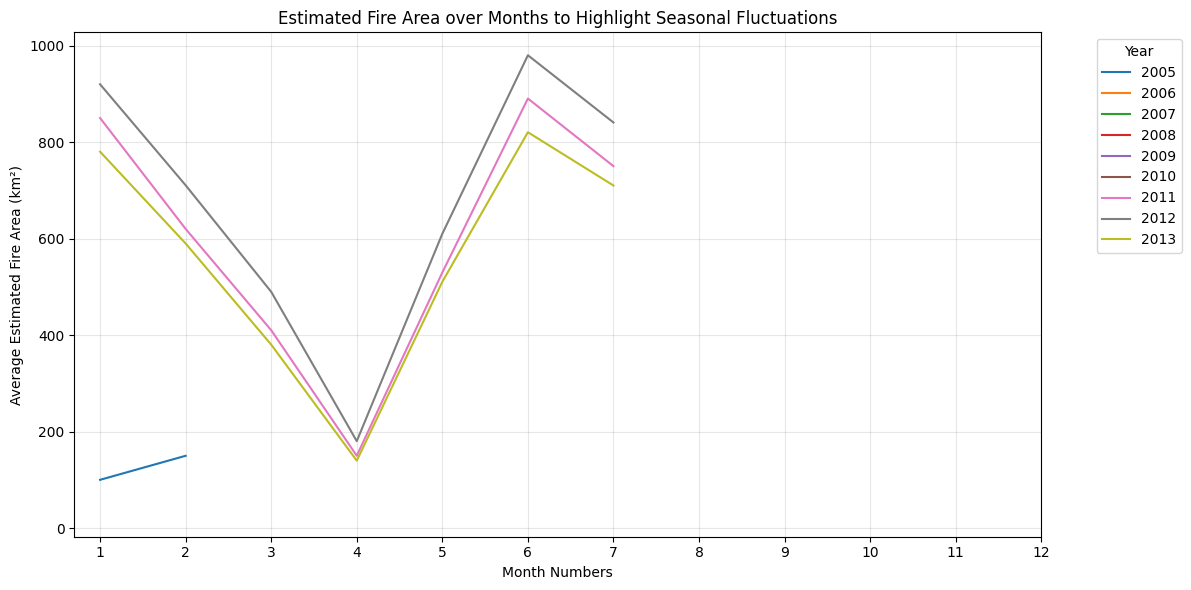

/tmp/ipykernel_337/1729798530.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness', palette='YlOrRd')


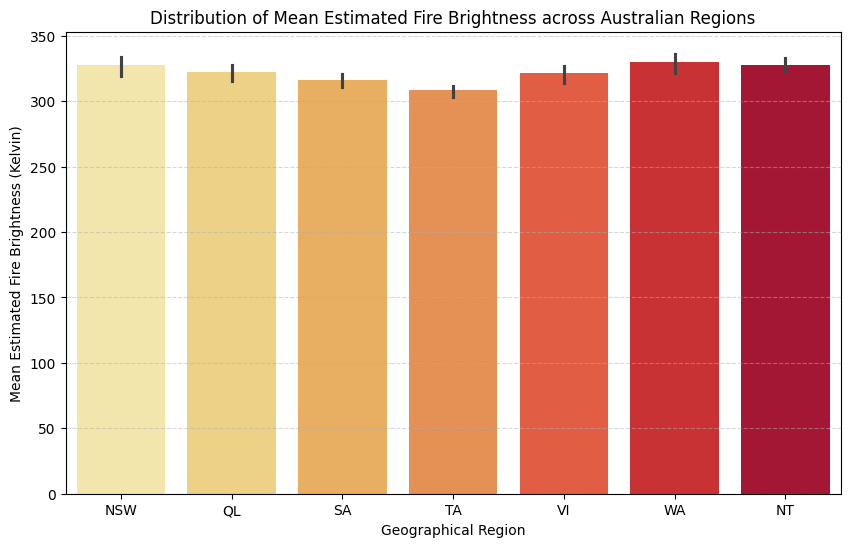

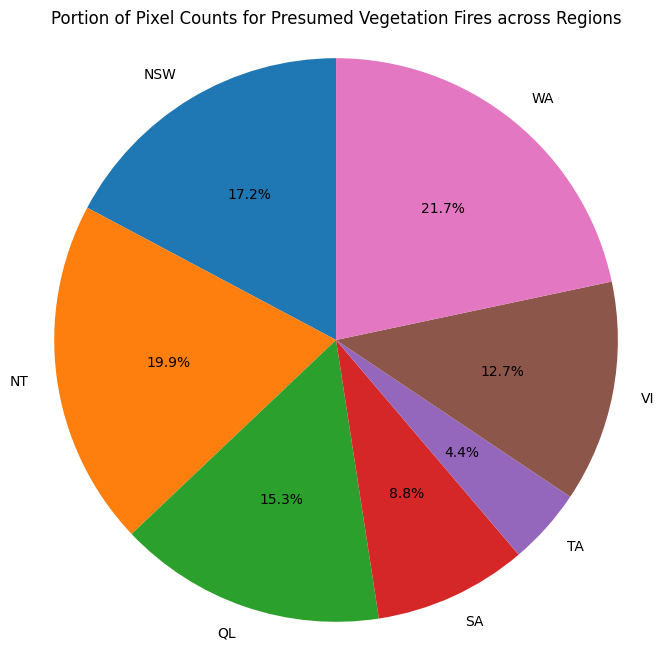

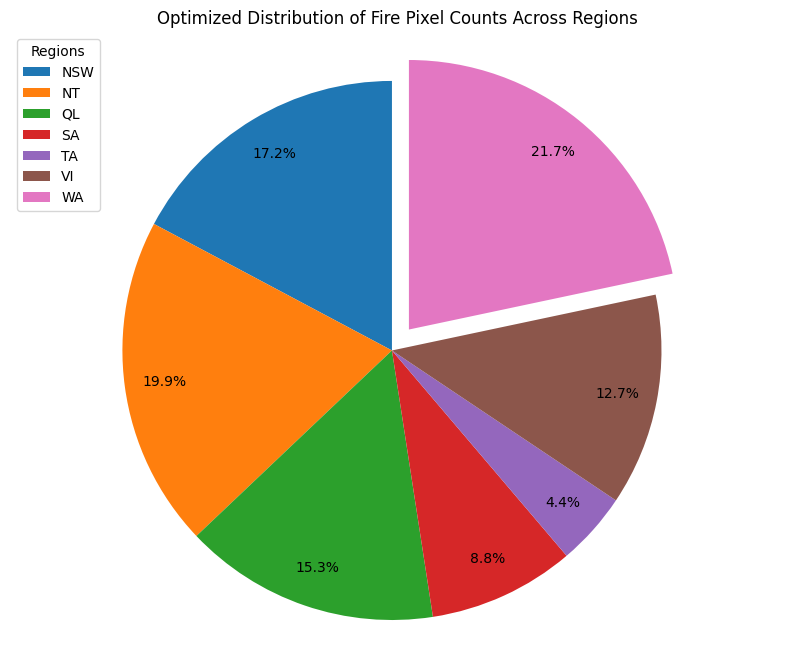

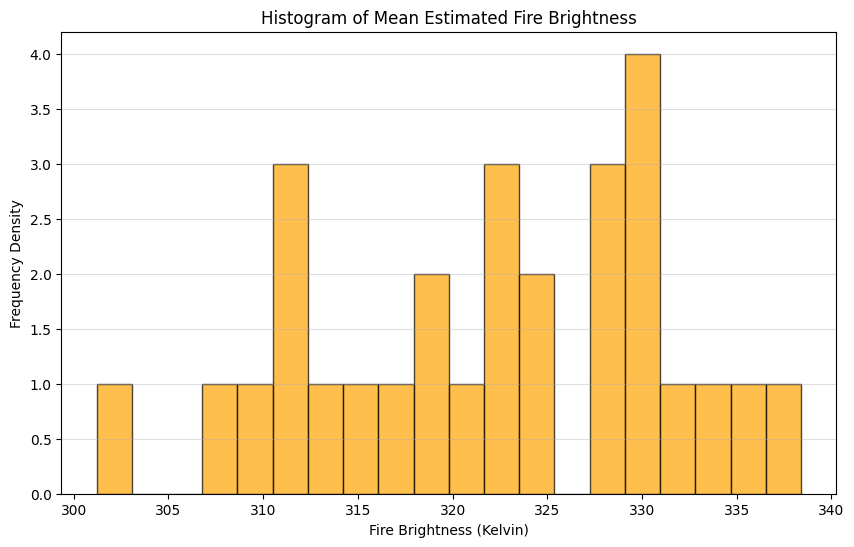

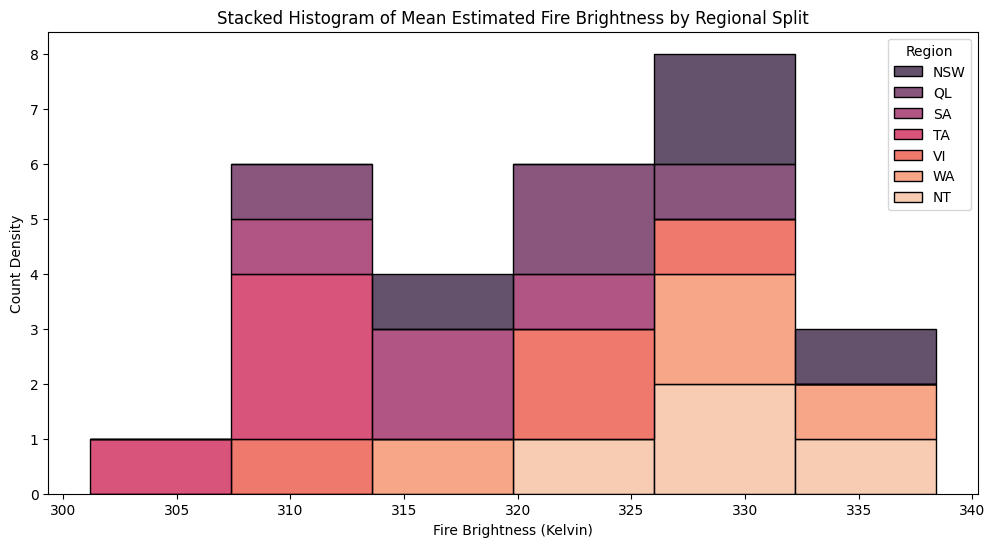

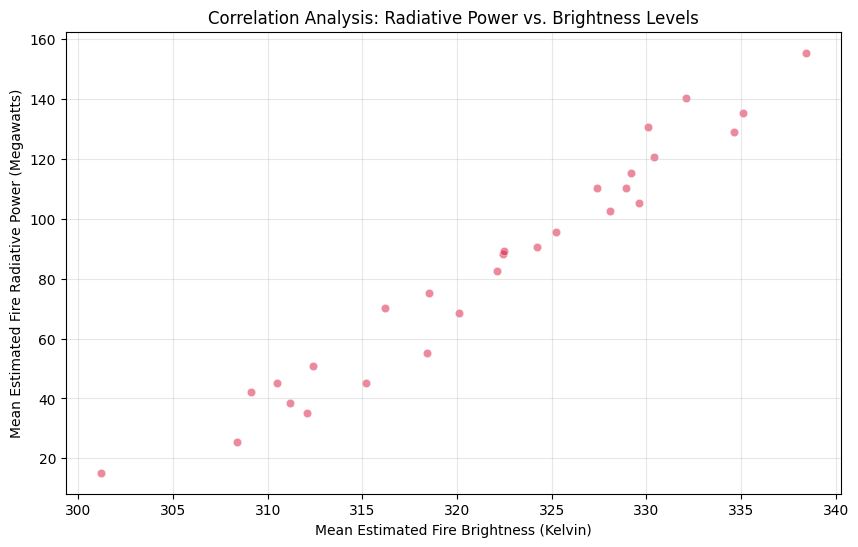

In [ ]:

# TOPIC: Analyzing Wildfire Activities in Australia (Offline Version)

import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

csv_data = """
Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Count
NSW,2005-01-01,100.5,315.2,45.3,120
NSW,2011-01-01,850.2,330.4,120.5,450
NSW,2012-01-01,920.1,335.1,135.2,510
NSW,2013-01-01,780.4,328.9,110.4,390
QL,2005-02-01,150.3,312.1,35.1,180
QL,2011-02-01,620.4,325.2,95.4,380
QL,2012-02-01,710.8,329.6,105.1,410
QL,2013-02-01,590.2,322.4,88.3,340
SA,2006-03-01,85.2,308.4,25.6,90
SA,2011-03-01,410.5,318.5,75.2,210
SA,2012-03-01,490.1,322.1,82.4,260
SA,2013-03-01,380.6,316.2,70.1,190
TA,2007-04-01,30.1,301.2,15.2,40
TA,2011-04-01,150.3,310.5,45.2,110
TA,2012-04-01,180.6,312.4,50.8,130
TA,2013-04-01,140.2,309.1,42.1,95
VI,2008-05-01,95.4,311.2,38.5,115
VI,2011-05-01,530.1,324.2,90.4,310
VI,2012-05-01,610.4,328.1,102.6,370
VI,2013-05-01,510.9,322.5,89.1,290
WA,2009-06-01,210.6,318.4,55.1,240
WA,2011-06-01,890.5,332.1,140.2,530
WA,2012-06-01,980.2,338.4,155.4,590
WA,2013-06-01,820.7,330.1,130.5,490
NT,2010-07-01,310.2,320.1,68.4,295
NT,2011-07-01,750.4,329.2,115.3,460
NT,2012-07-01,840.9,334.6,128.9,520
NT,2013-07-01,710.3,327.4,110.2,420
"""

df = pd.read_csv(io.StringIO(csv_data.strip()))
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


# --- TASK 1.1: Plotting a line chart showing change in average estimated fire area over time ---
plt.figure(figsize=(12, 6))
df_task1 = df.groupby('Year')['Estimated_fire_area'].mean().reset_index()
plt.plot(df_task1['Year'], df_task1['Estimated_fire_area'], marker='o', color='darkred', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time in Australia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- TASK 1.2: Plotting the estimated fire area over the months to identify seasonal patterns ---
plt.figure(figsize=(12, 6))
df_task2 = df.groupby(['Year', 'Month'])['Estimated_fire_area'].mean().reset_index()
sns.lineplot(data=df_task2, x='Month', y='Estimated_fire_area', hue='Year', palette='tab10')
plt.xlabel('Month Numbers')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Months to Highlight Seasonal Fluctuations')
plt.xticks(range(1, 13))
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- TASK 1.3: Creating a bar plot displaying distribution of mean estimated fire brightness across regions ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness', palette='YlOrRd')
plt.xlabel('Geographical Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Australian Regions')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# --- TASK 1.4: Developing a pie chart showing the portion of pixel counts for presumed vegetation fires ---
plt.figure(figsize=(8, 8))
region_counts = df.groupby('Region')['Count'].sum()
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Portion of Pixel Counts for Presumed Vegetation Fires across Regions')
plt.axis('equal')
plt.show()


# --- TASK 1.5: Customizing the pie plot for better visual representation (Exploding & Adding Legend) ---
plt.figure(figsize=(10, 8))
region_counts = df.groupby('Region')['Count'].sum()
explode_list = [0.1 if i == region_counts.idxmax() else 0 for i in region_counts.index]

plt.pie(region_counts, labels=None, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=explode_list)
plt.title('Optimized Distribution of Fire Pixel Counts Across Regions')
plt.legend(labels=region_counts.index, loc='upper left', title="Regions")
plt.axis('equal')
plt.show()


# --- TASK 1.6: Developing a histogram of mean estimated fire brightness to observe the distribution ---
plt.figure(figsize=(10, 6))
plt.hist(df['Mean_estimated_fire_brightness'], bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel('Fire Brightness (Kelvin)')
plt.ylabel('Frequency Density')
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.grid(axis='y', alpha=0.4)
plt.show()


# --- TASK 1.7: Using Seaborn pass 'Region' as hue parameter to check brightness distribution by region ---
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack', palette='rocket')
plt.xlabel('Fire Brightness (Kelvin)')
plt.ylabel('Count Density')
plt.title('Stacked Histogram of Mean Estimated Fire Brightness by Regional Split')
plt.show()


# --- TASK 1.8: Determining if there is a correlation between fire radiative power and fire brightness ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mean_estimated_fire_brightness', y='Mean_estimated_fire_radiative_power', alpha=0.5, color='crimson')
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Mean Estimated Fire Radiative Power (Megawatts)')
plt.title('Correlation Analysis: Radiative Power vs. Brightness Levels')
plt.grid(True, alpha=0.3)
plt.show()


# --- TASK 1.9: Marking these seven regions on the Map of Australia using Folium ---
region_data = {
    'region': ['NSW', 'QL', 'SA', 'TA', 'VI', 'WA', 'NT'],
    'Lat': [-31.8759835, -22.1646782, -30.5343665, -42.035067, -36.5986096, -25.2303005, -19.491411],
    'Lon': [147.2869493, 144.5844903, 135.6301212, 146.6366887, 144.6780052, 121.0187246, 132.550964]
}
reg = pd.DataFrame(region_data)

Australia_map = folium.Map(location=[-25, 135], zoom_start=4)
regions_group = folium.map.FeatureGroup()

for lat, lng, label in zip(reg.Lat, reg.Lon, reg.region):
    regions_group.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='red',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=label
        )
    )

Australia_map.add_child(regions_group)
Australia_map


In [2]:
!pip install dash plotly pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 61.8 MB/s eta 0:00:00


In [ ]:
# Dashboard for Visualizing Wildfire Activities in Australia using Dash
# TOPIC: Interactive Web Application for Data Exploration


import io
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px

# Raw inline data setup
csv_data = """
Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Count
NSW,2005-01-01,100.5,315.2,45.3,120
NSW,2011-01-01,850.2,330.4,120.5,450
NSW,2012-01-01,920.1,335.1,135.2,510
NSW,2013-01-01,780.4,328.9,110.4,390
QL,2005-02-01,150.3,312.1,35.1,180
QL,2011-02-01,620.4,325.2,95.4,380
QL,2012-02-01,710.8,329.6,105.1,410
QL,2013-02-01,590.2,322.4,88.3,340
SA,2006-03-01,85.2,308.4,25.6,90
SA,2011-03-01,410.5,318.5,75.2,210
SA,2012-03-01,490.1,322.1,82.4,260
SA,2013-03-01,380.6,316.2,70.1,190
TA,2007-04-01,30.1,301.2,15.2,40
TA,2011-04-01,150.3,310.5,45.2,110
TA,2012-04-01,180.6,312.4,50.8,130
TA,2013-04-01,140.2,309.1,42.1,95
VI,2008-05-01,95.4,311.2,38.5,115
VI,2011-05-01,530.1,324.2,90.4,310
VI,2012-05-01,610.4,328.1,102.6,370
VI,2013-05-01,510.9,322.5,89.1,290
WA,2009-06-01,210.6,318.4,55.1,240
WA,2011-06-01,890.5,332.1,140.2,530
WA,2012-06-01,980.2,338.4,155.4,590
WA,2013-06-01,820.7,330.1,130.5,490
NT,2010-07-01,310.2,320.1,68.4,295
NT,2011-07-01,750.4,329.2,115.3,460
NT,2012-07-01,840.9,334.6,128.9,520
NT,2013-07-01,710.3,327.4,110.2,420
"""

df = pd.read_csv(io.StringIO(csv_data.strip()))
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Initialize Dash App
app = dash.Dash(__name__)
app.title = "Australia Wildfire Dashboard"

# TASK 2.1 & 2.2 & 2.3: Layout Architecture
app.layout = html.Div([
    html.H1('Australia Wildfire Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'fontSize': '26px'}),
    html.Div([
        html.H2('Select Region:', style={'margin-right': '2em'}),
        dcc.RadioItems(
            id='region-radio',
            options=[{'label': x, 'value': x} for x in ['NSW', 'QL', 'SA', 'TA', 'VI', 'WA', 'NT']],
            value='NSW',
            inline=True
        ),
    ]),
    html.Div([
        html.Div([], id='plot1', style={'width': '50%'}),
        html.Div([], id='plot2', style={'width': '50%'})
    ], style={'display': 'flex'}),
])

# TASK 2.4 & 2.5 & 2.6: High-Speed Callback Engine
@app.callback(
    [Output('plot1', 'children'), Output('plot2', 'children')],
    [Input('region-radio', 'value')]
)
def reg_report(input_region):
    region_df = df[df['Region'] == input_region]

    # Render Plot 1
    fig1 = px.line(region_df, x='Month', y='Estimated_fire_area', color='Year',
                   title=f'{input_region}: Avg Fire Area')

    # Render Plot 2
    fig2 = px.line(region_df, x='Month', y='Count', color='Year',
                   title=f'{input_region}: Fire Count')

    return [dcc.Graph(figure=fig1), dcc.Graph(figure=fig2)]

# Run server safely with minimal parameters
if __name__ == '__main__':
    # FIXED: Cleaned options to avoid breaking flask configuration engine
    app.run(debug=False)


Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
